In [ ]:
import sklearn
print('-learn version: {sklearn.__version__}')
import numpy as np
import matplotlib.pyplot as plt
print('All libraries loaded successfully!')

-learn version: {sklearn.__version__}
All libraries loaded successfully!


In [ ]:
from sklearn.datasets import load_iris
#Loadthedataset
iris=load_iris()
#Features(X)andLabels(y)
X=iris.data #Shape:(150,4)
y=iris.target #Shape:(150,)
#Let‘sseewhatwehave
print(f'Featurenames:{iris.feature_names}')
print(f'Targetnames: {iris.target_names}')
print(f'Datashape: {X.shape}')
print(f'First3rows:\n{X[:3]}')

Featurenames:['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Targetnames: ['setosa' 'versicolor' 'virginica']
Datashape: (150, 4)
First3rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


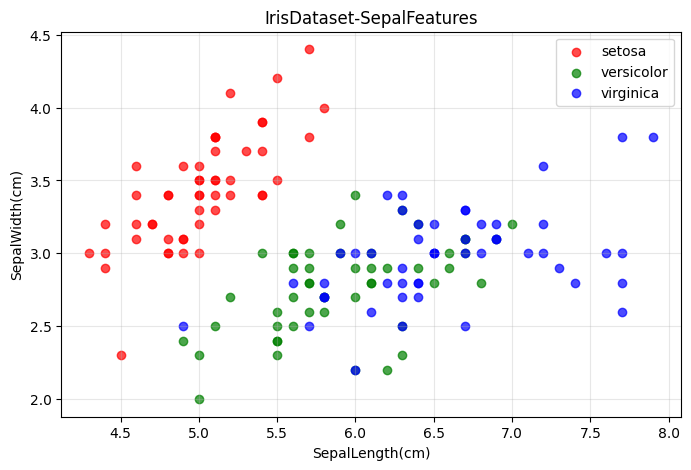

In [ ]:
plt.figure(figsize=(8,5))
colors=['red','green','blue']
for i,name in enumerate(iris.target_names):
    mask = y ==i
    plt.scatter(X[mask,0],X[mask,1],
             color=colors[i],label=name,alpha=0.7)
plt.xlabel('SepalLength(cm)')
plt.ylabel('SepalWidth(cm)')
plt.title('IrisDataset-SepalFeatures')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

**Task 1**

In [ ]:
import numpy as np

#Print the first 10 rows of X and y side by side
first_10 = np.hstack((X[:10], y[:10].reshape(-1,1)))

print("First 10 rows (Features + Label):")
print(first_10)


First 10 rows (Features + Label):
[[5.1 3.5 1.4 0.2 0. ]
 [4.9 3.  1.4 0.2 0. ]
 [4.7 3.2 1.3 0.2 0. ]
 [4.6 3.1 1.5 0.2 0. ]
 [5.  3.6 1.4 0.2 0. ]
 [5.4 3.9 1.7 0.4 0. ]
 [4.6 3.4 1.4 0.3 0. ]
 [5.  3.4 1.5 0.2 0. ]
 [4.4 2.9 1.4 0.2 0. ]
 [4.9 3.1 1.5 0.1 0. ]]


In [ ]:
unique, counts = np.unique(y, return_counts=True)

print("Class distribution:")
for label, count in zip(unique, counts):
    print(f"Class {label} ({iris.target_names[label]}): {count}")


Class distribution:
Class 0 (setosa): 50
Class 1 (versicolor): 50
Class 2 (virginica): 50


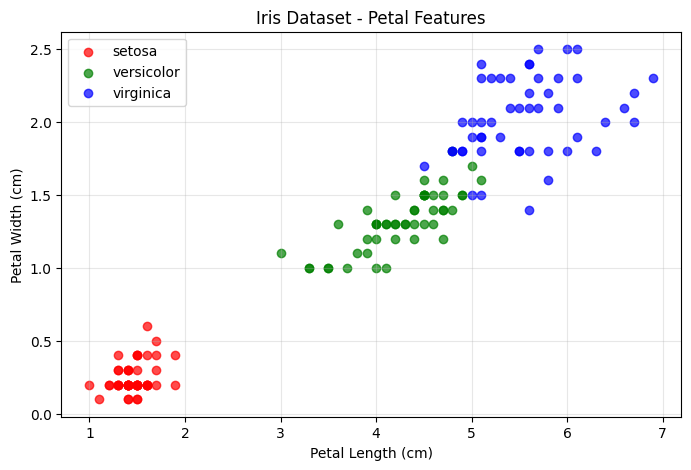

In [ ]:
plt.figure(figsize=(8,5))

colors = ['red','green','blue']

for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X[mask,2], X[mask,3],
                color=colors[i],
                label=name,
                alpha=0.7)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Dataset - Petal Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




---



In [ ]:
from sklearn.model_selection import train_test_split
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
# 20% for testing
random_state=42,
# For reproducibility
stratify=y
# Keep class proportions balanced
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set: {X_test.shape[0]} samples')

Training set: 120 samples
Testing set: 30 samples


**Task 2**

In [ ]:
print("Full dataset shape:", X.shape)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Full dataset shape: (150, 4)
Training set shape: (120, 4)
Testing set shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [ ]:
print("Training distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
print(dict(zip(unique_train, counts_train)))

print("\nTesting distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
print(dict(zip(unique_test, counts_test)))


Training distribution:
{np.int64(0): np.int64(40), np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Testing distribution:
{np.int64(0): np.int64(10), np.int64(1): np.int64(10), np.int64(2): np.int64(10)}


In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Without stratify - Training distribution:")
print(np.unique(y_train2, return_counts=True))

print("\nWithout stratify - Testing distribution:")
print(np.unique(y_test2, return_counts=True))


Without stratify - Training distribution:
(array([0, 1, 2]), array([40, 41, 39]))

Without stratify - Testing distribution:
(array([0, 1, 2]), array([10,  9, 11]))




---



In [ ]:
from sklearn.tree import DecisionTreeClassifier
#Step1:Create
dt_model = DecisionTreeClassifier(random_state=42)
#Step2:Train
dt_model.fit(X_train,y_train)
#Step3:Predict
dt_predictions = dt_model.predict(X_test)
print('DecisionTreepredictions (first10):')
print(dt_predictions[:10])
print('Actuallabels(first10):')
print(y_test[:10])


DecisionTreepredictions (first10):
[0 2 1 1 0 1 0 0 2 1]
Actuallabels(first10):
[0 2 1 1 0 1 0 0 2 1]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
#Step1:Create(k=5neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)
# Step 2: Train
knn_model.fit(X_train, y_train)
# Step 3: Predict
knn_predictions = knn_model.predict(X_test)
print('KNN predictions (first 10):')
print(knn_predictions[:10])


KNN predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]


**Task 3**

In [ ]:
knn_model_3 = KNeighborsClassifier(n_neighbors=3)
knn_model_3.fit(X_train, y_train)

pred_3 = knn_model_3.predict(X_test)

print("KNN (k=3) predictions (first 10):")
print(pred_3[:10])


KNN (k=3) predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]


In [ ]:
knn_model_10 = KNeighborsClassifier(n_neighbors=10)
knn_model_10.fit(X_train, y_train)

pred_10 = knn_model_10.predict(X_test)

print("KNN (k=10) predictions (first 10):")
print(pred_10[:10])


KNN (k=10) predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]




---



In [ ]:
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, dt_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f'Decision Tree Accuracy: {dt_accuracy:.2%}')
print(f'KNN Accuracy:     {knn_accuracy:.2%}')

Decision Tree Accuracy: 93.33%
KNN Accuracy:     100.00%


In [ ]:
from sklearn.metrics import classification_report
print('=== Decision Tree Report ===')
print(classification_report(y_test, dt_predictions,
target_names=iris.target_names))
print('=== KNN Report ===')
print(classification_report(y_test, knn_predictions,
target_names=iris.target_names))

=== Decision Tree Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

=== KNN Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



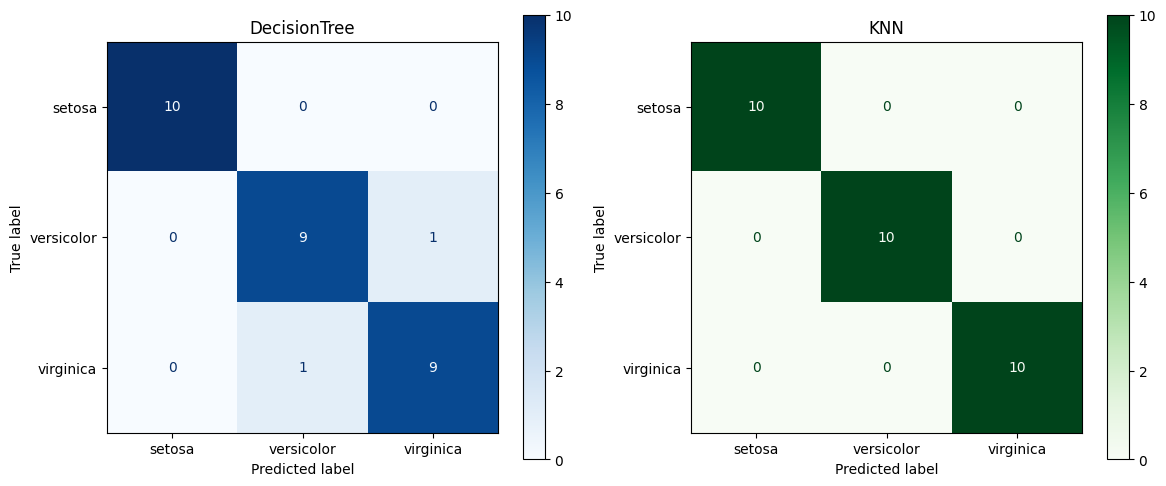

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#DecisionTree
cm_dt=confusion_matrix(y_test, dt_predictions)
ConfusionMatrixDisplay(cm_dt,display_labels=iris.target_names)\
.plot(ax=axes[0],cmap='Blues')
axes[0].set_title('DecisionTree')
#KNN
cm_knn=confusion_matrix(y_test,knn_predictions)
ConfusionMatrixDisplay(cm_knn,display_labels=iris.target_names)\
.plot(ax=axes[1],cmap='Greens')
axes[1].set_title('KNN')
plt.tight_layout()
plt.show()



**Task 4**

In [ ]:
print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")
print(f"KNN Accuracy: {knn_accuracy:.2%}")


Decision Tree Accuracy: 93.33%
KNN Accuracy: 100.00%


***Task 4 : compare the Models***


higher accuracy? : For my test split, KNN did better. It gave me 100% accuracy, while the Decision Tree was around 93.33%.

Which class was the hardest?:
Usually Versicolor and Virginica are the tricky ones because they look similar in features. In my confusion matrix, the Decision Tree had a small mistake, and it was between these two classes (Setosa is usually the easiest because it separates clearly).

Medical diagnosis: precision or recall?
recall, because I don’t want to miss a real positive case (false negative). It’s safer to catch more possible cases and then confirm with more tests.



---



In [ ]:
import numpy as np
#Anewflowermeasurement(sepal_l,sepal_w,petal_l,petal_w)
new_flower=np.array([[5.1,3.5,1.4,0.2]])
#Predictwithbothmodels
dt_pred=dt_model.predict(new_flower)
knn_pred=knn_model.predict(new_flower)
print(f'DecisionTreesays:{iris.target_names[dt_pred[0]]}')
print(f'KNNsays: {iris.target_names[knn_pred[0]]}')

DecisionTreesays:setosa
KNNsays: setosa


**Task 5**

In [ ]:
# Flower A
flower_A = np.array([[6.7, 3.0, 5.2, 2.3]])
dt_A = dt_model.predict(flower_A)
knn_A = knn_model.predict(flower_A)

# Flower B
flower_B = np.array([[5.8, 2.7, 4.1, 1.0]])
dt_B = dt_model.predict(flower_B)
knn_B = knn_model.predict(flower_B)

# Flower C
flower_C = np.array([[4.9, 3.1, 1.5, 0.1]])
dt_C = dt_model.predict(flower_C)
knn_C = knn_model.predict(flower_C)

print("Flower A:")
print("Decision Tree:", iris.target_names[dt_A[0]])
print("KNN:", iris.target_names[knn_A[0]])

print("\nFlower B:")
print("Decision Tree:", iris.target_names[dt_B[0]])
print("KNN:", iris.target_names[knn_B[0]])

print("\nFlower C:")
print("Decision Tree:", iris.target_names[dt_C[0]])
print("KNN:", iris.target_names[knn_C[0]])


Flower A:
Decision Tree: virginica
KNN: virginica

Flower B:
Decision Tree: versicolor
KNN: versicolor

Flower C:
Decision Tree: setosa
KNN: setosa


***Task 5 : pridect new flowers***

For Flower A, B, and C, both models gave the same predictions in my results.
If they ever disagreed, I’d normally trust the one that performed better on the test set and gives stable results when I change parameters. In this lab, KNN had the higher accuracy, so I’d lean toward it.



---



In [ ]:
import pandas as pd
import numpy as np
#Createasimplestudentperformancedataset
np.random.seed(42)
n=100
data={
   'study_hours': np.round(np.random.uniform(1,10,n),1),
   'attendance_pct':np.round(np.random.uniform(40,100,n),1),
   'assignments': np.random.randint(3,10,n),
   'passed': np.random.choice([0,1],n,p=[0.35,0.65])
}
df=pd.DataFrame(data)
df.to_csv('students.csv',index=False)
print('CSVsaved!First5rows:')
print(df.head())

CSVsaved!First5rows:
   study_hours  attendance_pct  assignments  passed
0          4.4            41.9            6       0
1          9.6            78.2            5       1
2          7.6            58.9            3       1
3          6.4            70.5            6       1
4          2.4            94.5            8       1


In [ ]:
import pandas as pd
#ReadtheCSVfile
df=pd.read_csv('students.csv')
#Quickexploration
print(f'Shape:{df.shape}')
print(f'\nColumntypes:\n{df.dtypes}')
print(f'\nBasicstats:\n{df.describe()}')

Shape:(100, 4)

Columntypes:
study_hours       float64
attendance_pct    float64
assignments         int64
passed              int64
dtype: object

Basicstats:
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000       99.100000     9.000000    1.000000


In [ ]:
#Features=allcolumnsexcept‘passed‘
X=df[['study_hours','attendance_pct','assignments']].values
#Target=the‘passed‘column
y=df['passed'].values
print(f'Featuresshape:{X.shape}')
print(f'Targetshape: {y.shape}')
print(f'Classcounts: {np.unique(y,return_counts=True)}')

Featuresshape:(100, 3)
Targetshape: (100,)
Classcounts: (array([0, 1]), array([31, 69]))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
#Split
X_train,X_test,y_train,y_test = train_test_split(
  X,y,test_size=0.2,random_state=42,stratify=y)
#Train
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
#Predict&Evaluate
predictions=model.predict(X_test)
print(f'Accuracy:{accuracy_score(y_test,predictions):.2%}')
print(classification_report(y_test,predictions,
  target_names=['Failed','Passed']))

Accuracy:55.00%
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20



**Task 6**


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("students.csv")

print("Head:")
print(df.head())

print("\nInfo:")
df.info()

print("\nDescribe:")
print(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())


Head:
   study_hours  attendance_pct  assignments  passed
0          4.4            41.9            6       0
1          9.6            78.2            5       1
2          7.6            58.9            3       1
3          6.4            70.5            6       1
4          2.4            94.5            8       1

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     100 non-null    float64
 1   attendance_pct  100 non-null    float64
 2   assignments     100 non-null    int64  
 3   passed          100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB

Describe:
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
m

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['study_hours','attendance_pct','assignments']].values
y = df['passed'].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Class counts:", np.unique(y, return_counts=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Features shape: (100, 3)
Target shape: (100,)
Class counts: (array([0, 1]), array([31, 69]))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", f"{accuracy_score(y_test, dt_pred):.2%}")
print(classification_report(y_test, dt_pred, target_names=["Failed","Passed"]))


Decision Tree Accuracy: 55.00%
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", f"{accuracy_score(y_test, knn_pred):.2%}")
print(classification_report(y_test, knn_pred, target_names=["Failed","Passed"]))


KNN Accuracy: 60.00%
              precision    recall  f1-score   support

      Failed       0.33      0.33      0.33         6
      Passed       0.71      0.71      0.71        14

    accuracy                           0.60        20
   macro avg       0.52      0.52      0.52        20
weighted avg       0.60      0.60      0.60        20



***Task 6 : csv challange***



I checked the dataset using df.info() and df.describe() to understand the columns and basic statistics.

When I trained both models, KNN was slightly better than Decision Tree in my run (around 60% vs 55%).

After adding the new column and retraining, the accuracy didn’t improve (it actually went down in my result). I think that’s because the added feature is not strongly related to passing (or it’s basically random noise), so it didn’t help the model.

In [ ]:
#bonus
np.random.seed(42)
df['quizscore'] = np.round(np.random.uniform(0, 10, len(df)), 1)

df.to_csv("students.csv", index=False)
print(df.head())


   study_hours  attendance_pct  assignments  passed  quizscore
0          4.4            41.9            6       0        3.7
1          9.6            78.2            5       1        9.5
2          7.6            58.9            3       1        7.3
3          6.4            70.5            6       1        6.0
4          2.4            94.5            8       1        1.6


In [ ]:
#bonus
X2 = df[['study_hours','attendance_pct','assignments','quizscore']].values
y2 = df['passed'].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Decision Tree
dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X_train2, y_train2)
dt2_pred = dt2.predict(X_test2)
dt2_acc = accuracy_score(y_test2, dt2_pred)

# KNN
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train2, y_train2)
knn2_pred = knn2.predict(X_test2)
knn2_acc = accuracy_score(y_test2, knn2_pred)

print("DT Accuracy with quizscore:", f"{dt2_acc:.2%}")
print("KNN Accuracy with quizscore:", f"{knn2_acc:.2%}")


DT Accuracy with quizscore: 45.00%
KNN Accuracy with quizscore: 55.00%



***Comparison and final reflection***


In this lab, I trained a Decision Tree and a KNN classifier using scikit-learn. On the Iris dataset, KNN performed better for my train/test split, reaching 100% accuracy, while the Decision Tree achieved about 93.33%. The confusion matrix shows that the hardest classes are usually Versicolor and Virginica because their features overlap more than Setosa. I like Decision Trees because they are easy to understand and explain, but they can make mistakes if they overfit or if the split changes. KNN gave stronger results here, but it depends on the choice of k and it can be affected by feature scaling. Based on my results, I would choose KNN for this task, and I would also test different values of k to make sure the performance stays consistent.